In [ ]:
import pandas as pd
df = pd.read_csv("/content/fake reviews dataset.csv")

In [ ]:
df.head(4)

In [ ]:
df = df.rename(columns={'text_': 'text'})

In [ ]:
print(df['label'].unique())
print(df.columns)
print(df[['label']].head(10))

In [ ]:
df['label'] = df['label'].map({'CG': 1, 'OR': 0})

In [ ]:
df.head(4)

In [ ]:
# Check missing values
print(df.isnull().sum())

# Drop rows where 'text' is null or empty
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != ""]

# For category/rating:
# - If very few missing, drop them
# - If many missing, you can impute (fillna with "unknown" or mean)

df['category'] = df['category'].fillna("unknown")
df['rating'] = df['rating'].fillna(df['rating'].mean())  # or median

In [ ]:
df.head(4)

In [ ]:
from sklearn.preprocessing import LabelEncoder
# create encoder
encoder = LabelEncoder()

# fit and transform
df['category_encoded'] = encoder.fit_transform(df['category'])

# check mapping
mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Category → Encoded mapping:", mapping)

In [ ]:
import re, string

def clean_text(text):
    text = str(text).lower()    # convert to lowercase
    text = re.sub(r'\d+', '', text)  #remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  #remove punctuations
    text = re.sub(r'\s+', ' ', text).strip()  #remove extra spaces
    return text
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df['clean_text'] = df['clean_text'].fillna("").astype(str)


In [ ]:
df.head(4)

In [ ]:
import numpy as np
from textblob import TextBlob

# Length features
df['review_length_words'] = df['clean_text'].apply(lambda x: len(x.split()))
df['review_length_chars'] = df['clean_text'].apply(len)
df['avg_word_length'] = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)

# Style features (use text_ since your column is named that)
df['num_exclamations'] = df['text'].apply(lambda x: str(x).count('!'))
df['num_uppercase'] = df['text'].apply(lambda x: sum(1 for w in str(x).split() if w.isupper()))

# Sentiment feature
df['sentiment_score'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Rating-based feature
df['extreme_rating'] = df['rating'].apply(lambda x: 1 if (x <= 2 or x >= 4) else 0)

#duplicate count
df['duplicate_count'] = df.groupby('text')['text'].transform('count')

In [ ]:
df.head(4)

In [ ]:
print(df.isnull().sum())
print((df['text'].str.strip() == "").sum())
print(df.duplicated(subset=['text']).sum())
print(df[['review_length_words','review_length_chars','avg_word_length']].describe())

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# -------------------------
# 1. Select features to normalize
# -------------------------
features = ['category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count']

# -------------------------
# 2. Initialize MinMaxScaler (scale to [0,1])
# -------------------------
scaler = MinMaxScaler(feature_range=(0, 1))

# -------------------------
# 3. Fit + Transform
# -------------------------
df[features] = scaler.fit_transform(df[features])

# -------------------------
# 4. (Optional) Save the scaler for later use
# -------------------------
# Save file in Colab environment
output_file = "fake_reviews_normalized.csv"
df.to_csv(output_file, index=False)

print(f"✅ File saved to: {output_file}")


In [ ]:
print("Dataset shape:", df.shape)
print("Unique labels:", df['label'].value_counts())


# Normal CNN Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# 1. Load + Split Dataset
# -------------------------
df = pd.read_csv("/content/fake_reviews_normalized.csv")

# Labels (force int32 for TensorFlow compatibility)
y = df['label'].astype(np.int32)

# Text (for CNN) and metadata (for RF in another notebook)
X_text = df['clean_text'].values
meta_features = [
    'category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count'
]
X_meta = df[meta_features].values

# Single train/test split shared by RF and CNN
# ✅ Corrected split
X_train_text, X_test_text, X_train_meta, X_test_meta, y_train, y_test = train_test_split(
    X_text, X_meta, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 32345
Test size: 8087


In [ ]:
# 🔹 Ensure no NaNs in training & test text
import pandas as pd
X_train_text = pd.Series(X_train_text).fillna("").astype(str)
X_test_text  = pd.Series(X_test_text).fillna("").astype(str)

# -------------------------
# 2. Tokenization + Padding
# -------------------------
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

max_len = max(len(seq) for seq in X_train_seq)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("CNN Train shape:", X_train_pad.shape)
print("CNN Test shape:", X_test_pad.shape)

# -------------------------
# 3. CNN Model
# -------------------------
embedding_dim = 100
filters = 128
kernel_size = 5
dropout_rate = 0.3

model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index)+1,output_dim=embedding_dim, input_length=max_len),
    Conv1D(filt ers=filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(dropout_rate),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001),
metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_pad,  y_test,  verbose=0)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

CNN Train shape: (32345, 369)
CNN Test shape: (8087, 369)
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


405/405 ━━━━━━━━━━━━━━━━━━━━ 102s 246ms/step - accuracy: 0.7889 - loss: 0.4462 - val_accuracy: 0.9318 - val_loss: 0.1768
Epoch 2/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 141s 245ms/step - accuracy: 0.9604 - loss: 0.1095 - val_accuracy: 0.9396 - val_loss: 0.1690
Epoch 3/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 142s 245ms/step - accuracy: 0.9855 - loss: 0.0450 - val_accuracy: 0.9377 - val_loss: 0.1901
Epoch 4/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 145s 254ms/step - accuracy: 0.9943 - loss: 0.0199 - val_accuracy: 0.9321 - val_loss: 0.2399
Epoch 5/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 138s 243ms/step - accuracy: 0.9956 - loss: 0.0134 - val_accuracy: 0.9278 - val_loss: 0.2853
Epoch 6/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 97s 238ms/step - accuracy: 0.9966 - loss: 0.0100 - val_accuracy: 0.9317 - val_loss: 0.3020
Epoch 7/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 102s 253ms/step - accuracy: 0.9954 - loss: 0.0129 - val_accuracy: 0.9328 - val_loss: 0.3066

Train Accuracy: 0.9792
Test  Accuracy: 0.9415


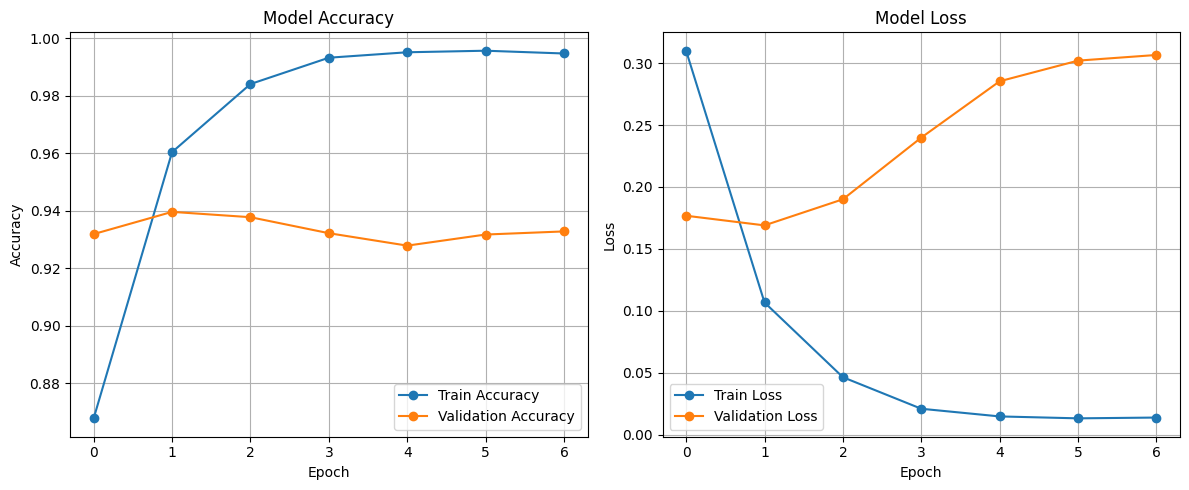

In [ ]:
# === Plot accuracy and loss ===
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


253/253 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step
Test Accuracy: 0.9415110671448003
Test Precision: 0.9636363636363636
Test Recall: 0.9176354192431363
Test F1-Score: 0.9400734828328899
Sum of confusion matrix: 8087


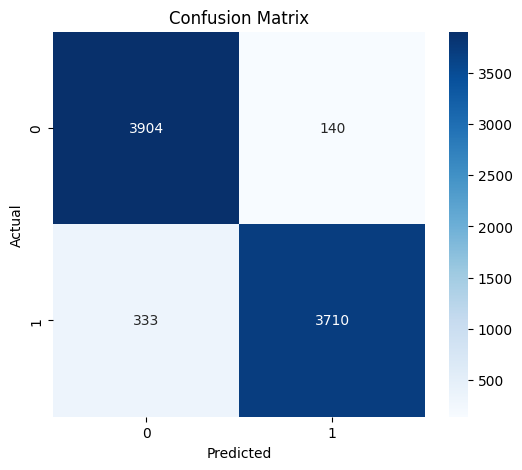

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred)
print("Test Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)

# F1-score
f1 = f1_score(y_test, y_pred)
print("Test F1-Score:", f1)

cm = confusion_matrix(y_test, y_pred)
print("Sum of confusion matrix:", cm.sum())
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predicted probabilities on test set
y_pred_prob = model.predict(X_test_pad)

# Try thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.91, 0.01)
best_threshold = 0.5
best_f1 = 0

print("Threshold  Precision  Recall  F1-Score")
print("-"*40)

for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    precision = precision_score(y_test.astype(int), y_pred)
    recall = recall_score(y_test.astype(int), y_pred)
    f1 = f1_score(y_test.astype(int), y_pred)

    print(f"{t:.2f}       {precision:.4f}    {recall:.4f}   {f1:.4f}")

    # Track the best threshold based on F1
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\n✅ Best Threshold:", best_threshold, "with F1-score:", best_f1)

253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
Threshold  Precision  Recall  F1-Score
----------------------------------------
0.10       0.8887    0.9721   0.9285
0.11       0.8925    0.9708   0.9300
0.12       0.8976    0.9691   0.9320
0.13       0.9013    0.9688   0.9338
0.14       0.9064    0.9671   0.9357
0.15       0.9088    0.9639   0.9355
0.16       0.9131    0.9622   0.9370
0.17       0.9154    0.9609   0.9376
0.18       0.9183    0.9592   0.9383
0.19       0.9208    0.9577   0.9389
0.20       0.9220    0.9555   0.9384
0.21       0.9237    0.9550   0.9391
0.22       0.9256    0.9545   0.9398
0.23       0.9282    0.9530   0.9404
0.24       0.9301    0.9510   0.9404
0.25       0.9317    0.9486   0.9401
0.26       0.9332    0.9473   0.9402
0.27       0.9350    0.9461   0.9405
0.28       0.9367    0.9443   0.9405
0.29       0.9378    0.9434   0.9406
0.30       0.9389    0.9419   0.9404
0.31       0.9411    0.9414   0.9413
0.32       0.9436    0.9394   0.9415
0.33       0.9440    0.9382

In [ ]:
import numpy as np
import pandas as pd

# (assuming best_threshold is already defined earlier)
# best_threshold = 0.889...

# Get probabilities for the test set
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to class labels using best_threshold
y_pred = (y_pred_prob >= best_threshold).astype(int)

# Build results DataFrame (no `.values` needed)
results_df = pd.DataFrame({
    "Review": np.array(X_test_text),
    "Actual Label": np.array(y_test),
    "Predicted Prob": y_pred_prob.flatten(),
    "Predicted Label": y_pred.flatten()
})

# Filter only the reviews predicted as FAKE (label = 1)
fake_reviews = results_df[results_df["Predicted Label"] == 1]

print("Detected Fake Reviews:", len(fake_reviews))

total_actual_fake = np.sum(y_test.astype(int) == 1)
print("Total Actual Fake Reviews in Test Set:", total_actual_fake)

253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
Detected Fake Reviews: 3960
Total Actual Fake Reviews in Test Set: 4043


In [ ]:
print("y_test shape:", y_test.shape)
print("Unique labels in y_test:", np.unique(y_test, return_counts=True))


y_test shape: (8087,)
Unique labels in y_test: (array([0, 1], dtype=int32), array([4044, 4043]))


# Deep CNN Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# 1. Load + Split Dataset
# -------------------------
df = pd.read_csv("/content/fake_reviews_normalized.csv")

# Labels (force int32 for TensorFlow compatibility)
y = df['label'].astype(np.int32)

# Text (for CNN) and metadata (for RF in another notebook)
X_text = df['clean_text'].values
meta_features = [
    'category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count'
]
X_meta = df[meta_features].values

# Single train/test split shared by RF and CNN
# ✅ Corrected split
X_train_text, X_test_text, X_train_meta, X_test_meta, y_train, y_test = train_test_split(
    X_text, X_meta, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 32345
Test size: 8087


In [ ]:
# 🔹 Ensure no NaNs in training & test text
import pandas as pd
X_train_text = pd.Series(X_train_text).fillna("").astype(str)
X_test_text  = pd.Series(X_test_text).fillna("").astype(str)

# -------------------------
# 2. Tokenization + Padding
# -------------------------
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

max_len = max(len(seq) for seq in X_train_seq)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("CNN Train shape:", X_train_pad.shape)
print("CNN Test shape:", X_test_pad.shape)

# -------------------------
# 3. Deep CNN Model
# -------------------------
embedding_dim = 200
filters = 256
kernel_size = 3
dropout_rate = 0.5

model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index)+1,
              output_dim=embedding_dim, input_length=max_len),
    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(dropout_rate),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=128,
    callbacks=[es],
    verbose=1
)

train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_pad,  y_test,  verbose=0)

print(f"\n[Deep CNN] Train Accuracy: {train_acc:.4f}")
print(f"[Deep CNN] Test  Accuracy: {test_acc:.4f}")

CNN Train shape: (32345, 369)
CNN Test shape: (8087, 369)
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


203/203 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.7611 - loss: 0.4574 - val_accuracy: 0.9284 - val_loss: 0.1755
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.9572 - loss: 0.1130 - val_accuracy: 0.9341 - val_loss: 0.1608
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.9803 - loss: 0.0539 - val_accuracy: 0.9346 - val_loss: 0.2017
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.9865 - loss: 0.0355 - val_accuracy: 0.9355 - val_loss: 0.2196
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.9927 - loss: 0.0193 - val_accuracy: 0.9392 - val_loss: 0.2458
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - accuracy: 0.9937 - loss: 0.0183 - val_accuracy: 0.9351 - val_loss: 0.2755
Epoch 7/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.9941 - loss: 0.0172 - val_accuracy: 0.9246 - val_loss: 0.3281

[Deep CNN] Train Accuracy: 0.9748
[Deep CNN] Test  Accuracy: 0.9402


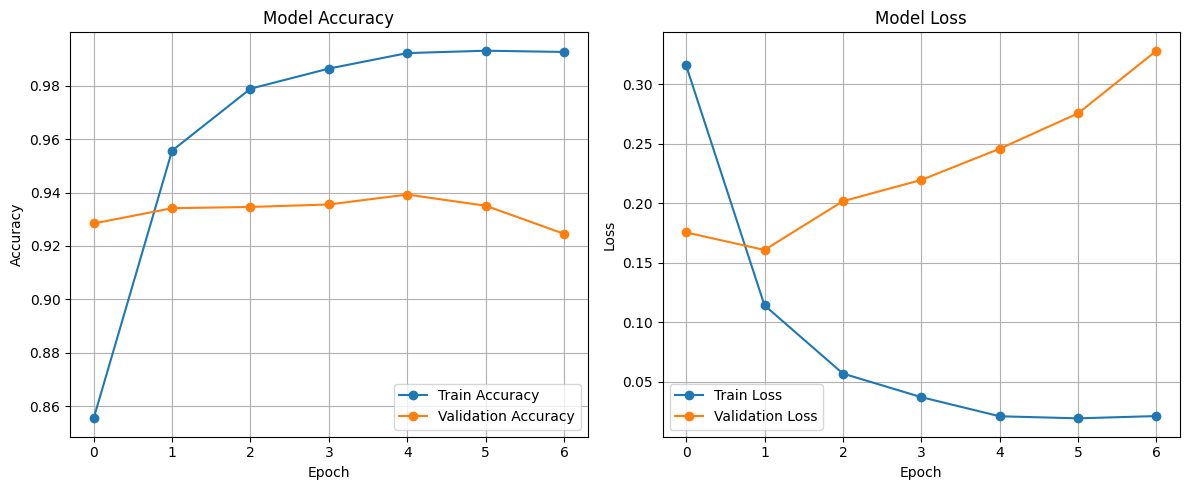

In [ ]:
# === Plot accuracy and loss ===
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


253/253 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step
Test Accuracy: 0.9401508594039817
Test Precision: 0.9589889089502193
Test Recall: 0.9196141479099679
Test F1-Score: 0.9388888888888889
Sum of confusion matrix: 8087


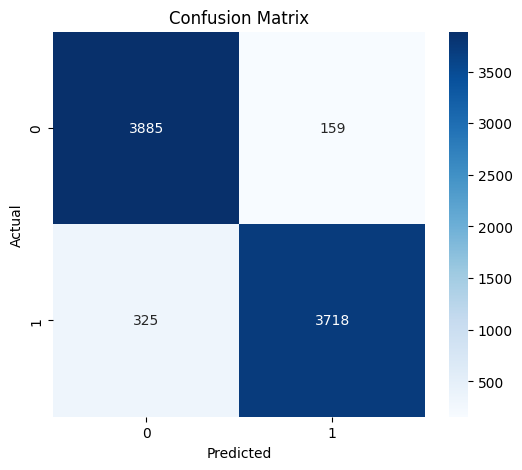

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred)
print("Test Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)

# F1-score
f1 = f1_score(y_test, y_pred)
print("Test F1-Score:", f1)

cm = confusion_matrix(y_test, y_pred)
print("Sum of confusion matrix:", cm.sum())
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predicted probabilities on test set
y_pred_prob = model.predict(X_test_pad)

# Try thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.91, 0.01)
best_threshold = 0.5
best_f1 = 0

print("Threshold  Precision  Recall  F1-Score")
print("-"*40)

for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    precision = precision_score(y_test.astype(int), y_pred)
    recall = recall_score(y_test.astype(int), y_pred)
    f1 = f1_score(y_test.astype(int), y_pred)

    print(f"{t:.2f}       {precision:.4f}    {recall:.4f}   {f1:.4f}")

    # Track the best threshold based on F1
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\n✅ Best Threshold:", best_threshold, "with F1-score:", best_f1)

253/253 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step
Threshold  Precision  Recall  F1-Score
----------------------------------------
0.10       0.8690    0.9763   0.9195
0.11       0.8736    0.9745   0.9213
0.12       0.8785    0.9730   0.9234
0.13       0.8826    0.9708   0.9246
0.14       0.8846    0.9686   0.9247
0.15       0.8899    0.9676   0.9271
0.16       0.8933    0.9651   0.9278
0.17       0.8975    0.9636   0.9294
0.18       0.9009    0.9629   0.9309
0.19       0.9040    0.9619   0.9321
0.20       0.9075    0.9604   0.9332
0.21       0.9101    0.9589   0.9339
0.22       0.9137    0.9580   0.9353
0.23       0.9162    0.9572   0.9363
0.24       0.9181    0.9570   0.9371
0.25       0.9205    0.9565   0.9381
0.26       0.9226    0.9552   0.9386
0.27       0.9249    0.9535   0.9390
0.28       0.9266    0.9520   0.9391
0.29       0.9294    0.9510   0.9401
0.30       0.9312    0.9500   0.9405
0.31       0.9327    0.9490   0.9408
0.32       0.9353    0.9478   0.9415
0.33       0.9366    0.94

In [ ]:
import numpy as np
import pandas as pd

# (assuming best_threshold is already defined earlier)
# best_threshold = 0.889...

# Get probabilities for the test set
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to class labels using best_threshold
y_pred = (y_pred_prob >= best_threshold).astype(int)

# Build results DataFrame (no `.values` needed)
results_df = pd.DataFrame({
    "Review": np.array(X_test_text),
    "Actual Label": np.array(y_test),
    "Predicted Prob": y_pred_prob.flatten(),
    "Predicted Label": y_pred.flatten()
})

# Filter only the reviews predicted as FAKE (label = 1)
fake_reviews = results_df[results_df["Predicted Label"] == 1]

print("Detected Fake Reviews:", len(fake_reviews))

total_actual_fake = np.sum(y_test.astype(int) == 1)
print("Total Actual Fake Reviews in Test Set:", total_actual_fake)

253/253 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step
Detected Fake Reviews: 4074
Total Actual Fake Reviews in Test Set: 4043


# Text CNN Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# 1. Load + Split Dataset
# -------------------------
df = pd.read_csv("/content/fake_reviews_normalized.csv")

# Labels (force int32 for TensorFlow compatibility)
y = df['label'].astype(np.int32)

# Text (for CNN) and metadata (for RF in another notebook)
X_text = df['clean_text'].values
meta_features = [
    'category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count'
]
X_meta = df[meta_features].values

# Single train/test split shared by RF and CNN
# ✅ Corrected split
X_train_text, X_test_text, X_train_meta, X_test_meta, y_train, y_test = train_test_split(
    X_text, X_meta, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 32345
Test size: 8087


In [ ]:
# 🔹 Ensure no NaNs in training & test text
import pandas as pd
X_train_text = pd.Series(X_train_text).fillna("").astype(str)
X_test_text  = pd.Series(X_test_text).fillna("").astype(str)

# -------------------------
# 2. Tokenization + Padding
# -------------------------
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

max_len = max(len(seq) for seq in X_train_seq)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("CNN Train shape:", X_train_pad.shape)
print("CNN Test shape:", X_test_pad.shape)

# -------------------------
# TextCNN (Multi-kernel CNN)
# -------------------------
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.models import Model

embedding_dim = 300
filters = 128
kernel_sizes = [3,4,5]
dropout_rate = 0.5

inputs = Input(shape=(max_len,))
x = Embedding(input_dim=len(tokenizer.word_index)+1,
              output_dim=embedding_dim, input_length=max_len)(inputs)

convs = []
for k in kernel_sizes:
    c = Conv1D(filters=filters, kernel_size=k, activation='relu')(x)
    p = GlobalMaxPooling1D()(c)
    convs.append(p)

x = Concatenate()(convs)
x = Dropout(dropout_rate)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=128,
    callbacks=[es],
    verbose=1
)

train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_pad,  y_test,  verbose=0)

print(f"\n[TextCNN] Train Accuracy: {train_acc:.4f}")
print(f"[TextCNN] Test  Accuracy: {test_acc:.4f}")

CNN Train shape: (32345, 369)
CNN Test shape: (8087, 369)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 605s 3s/step - accuracy: 0.7765 - loss: 0.4477 - val_accuracy: 0.9312 - val_loss: 0.1824
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 603s 3s/step - accuracy: 0.9621 - loss: 0.1077 - val_accuracy: 0.9416 - val_loss: 0.1567
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 620s 3s/step - accuracy: 0.9858 - loss: 0.0437 - val_accuracy: 0.9156 - val_loss: 0.2549
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 653s 3s/step - accuracy: 0.9917 - loss: 0.0225 - val_accuracy: 0.9413 - val_loss: 0.2191
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 596s 3s/step - accuracy: 0.9948 - loss: 0.0146 - val_accuracy: 0.9399 - val_loss: 0.2618
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 598s 3s/step - accuracy: 0.9951 - loss: 0.0138 - val_accuracy: 0.9382 - val_loss: 0.2825
Epoch 7/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 600s 3s/step - accuracy: 0.9951 - loss: 0.0133 - val_accuracy: 0.9343 - val_loss: 0.3062

[TextCNN] Train Accuracy: 0.9805
[TextCNN] Test  Accuracy: 0.9421


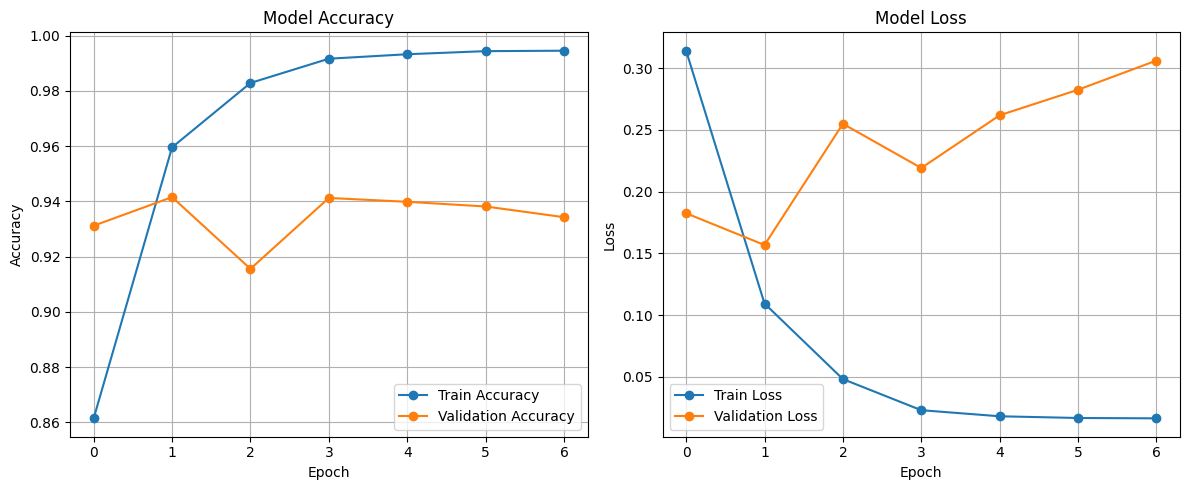

In [ ]:
# === Plot accuracy and loss ===
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


253/253 ━━━━━━━━━━━━━━━━━━━━ 46s 180ms/step
Test Accuracy: 0.9421293433906269
Test Precision: 0.959866220735786
Test Recall: 0.9228295819935691
Test F1-Score: 0.940983606557377
Sum of confusion matrix: 8087


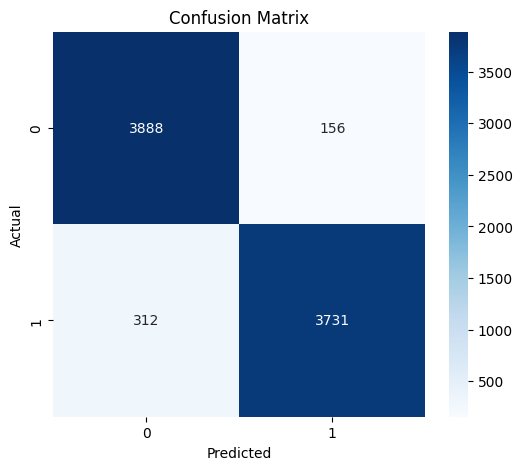

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred)
print("Test Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)

# F1-score
f1 = f1_score(y_test, y_pred)
print("Test F1-Score:", f1)

cm = confusion_matrix(y_test, y_pred)
print("Sum of confusion matrix:", cm.sum())
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predicted probabilities on test set
y_pred_prob = model.predict(X_test_pad)

# Try thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.91, 0.01)
best_threshold = 0.5
best_f1 = 0

print("Threshold  Precision  Recall  F1-Score")
print("-"*40)

for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    precision = precision_score(y_test.astype(int), y_pred)
    recall = recall_score(y_test.astype(int), y_pred)
    f1 = f1_score(y_test.astype(int), y_pred)

    print(f"{t:.2f}       {precision:.4f}    {recall:.4f}   {f1:.4f}")

    # Track the best threshold based on F1
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\n✅ Best Threshold:", best_threshold, "with F1-score:", best_f1)

253/253 ━━━━━━━━━━━━━━━━━━━━ 48s 191ms/step
Threshold  Precision  Recall  F1-Score
----------------------------------------
0.10       0.8781    0.9763   0.9246
0.11       0.8829    0.9755   0.9269
0.12       0.8889    0.9716   0.9284
0.13       0.8936    0.9701   0.9303
0.14       0.8961    0.9683   0.9308
0.15       0.8995    0.9671   0.9321
0.16       0.9016    0.9659   0.9326
0.17       0.9040    0.9639   0.9330
0.18       0.9059    0.9622   0.9332
0.19       0.9101    0.9612   0.9349
0.20       0.9124    0.9607   0.9359
0.21       0.9140    0.9594   0.9362
0.22       0.9163    0.9584   0.9369
0.23       0.9193    0.9580   0.9382
0.24       0.9219    0.9575   0.9393
0.25       0.9245    0.9565   0.9402
0.26       0.9266    0.9555   0.9408
0.27       0.9283    0.9545   0.9412
0.28       0.9300    0.9535   0.9416
0.29       0.9306    0.9520   0.9412
0.30       0.9318    0.9503   0.9410
0.31       0.9337    0.9481   0.9408
0.32       0.9360    0.9473   0.9416
0.33       0.9370    0.94

In [ ]:
import numpy as np
import pandas as pd

# (assuming best_threshold is already defined earlier)
# best_threshold = 0.889...

# Get probabilities for the test set
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to class labels using best_threshold
y_pred = (y_pred_prob >= best_threshold).astype(int)

# Build results DataFrame (no `.values` needed)
results_df = pd.DataFrame({
    "Review": np.array(X_test_text),
    "Actual Label": np.array(y_test),
    "Predicted Prob": y_pred_prob.flatten(),
    "Predicted Label": y_pred.flatten()
})

# Filter only the reviews predicted as FAKE (label = 1)
fake_reviews = results_df[results_df["Predicted Label"] == 1]

print("Detected Fake Reviews:", len(fake_reviews))

total_actual_fake = np.sum(y_test.astype(int) == 1)
print("Total Actual Fake Reviews in Test Set:", total_actual_fake)

253/253 ━━━━━━━━━━━━━━━━━━━━ 47s 185ms/step
Detected Fake Reviews: 4002
Total Actual Fake Reviews in Test Set: 4043
